# Modelado

In [1]:
import pandas as pd
import numpy as np 
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn import metrics  

import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

C:\Users\SANTIAGO\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Funciones y utilidades

In [2]:
def carga_info(data):
    drop_cols = [
        'Municipio', 
        'Departamento', 
        'EVI_Min_Date', 
        'EVI_Max_Date', 
        'NDVI_Min_Date', 
        'NDVI_Max_Date', 
        'NDVI_Max_Count', 
        #'Latitude', 
        #'Longitude', 
        'Producto', 
        'Área Cosechada', 
        'Área Sembrada', 
        'Ciclo',
        'Producción'
        ]
    
    #Creación de nuevas variables necesarias
    data['Mpio'] = data['Municipio'].str.strip()+'_'+data['Departamento'].str.strip()
    data['Flag_covid'] = np.where(data['Year']==2020, 1, 0)
    data.rename(columns={'EVI_Max_Count':'Resolucion'}, inplace=True)
    #Eliminación de columnas innecesarias
    data.drop(columns=drop_cols, inplace=True)
    #Eliminación de nuelos -- esto puede cambiar si decidimos hacer imputacion
    data.dropna(inplace=True)
    #Ordenamiento
    data = data[[
        'Year', 'Mpio', 
        't2m_mean', 'd2m_mean', 'tp_mean', 'ssrd_mean', 'e_mean', 'stl1_mean', 
        't2m_std', 'd2m_std', 'tp_std', 'ssrd_std', 'e_std', 'stl1_std', 
        'Resolucion',
       'EVI_Min_Minimum', 'EVI_Max_Maximum', 'EVI_Avg_StdDev', 'EVI_Avg_Mean_deviation', 'EVI_Avg_StdDev_deviation',
       'EVI_Median_Median', 'EVI_Avg_Mean', 'NDVI_Min_Minimum', 'NDVI_Avg_Mean_deviation', 'NDVI_Avg_StdDev_deviation',
       'NDVI_Max_Maximum', 'NDVI_Avg_StdDev', 'NDVI_Median_Median',
       'NDVI_Avg_Mean', 'Flag_covid', 'Rendimiento']]
    
    print(f'Data cargada para {data}')
    data.info()
    return data

def univariate_ols_analysis(df, target='Rendimiento', test_size=0.2, random_state=42, verbose=True):
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        df.drop(columns=[target]),
        df[target],
        test_size=test_size,
        random_state=random_state
    )
    
    predictors = X_train.columns
    results = []
    
    for pred in predictors:
        
        X = X_train[[pred]].copy()
        
        # Convertir categóricas a dummies
        if X.dtypes[0] == 'object':
            X = pd.get_dummies(X, drop_first=True)
        
            # Agregar intercepto
        X = sm.add_constant(X)
        
        # Fit modelo
        mod = sm.OLS(y_train, X)
        res = mod.fit()
        
        if verbose:
            print(f"\nResultados para predictor: {pred}")
            print(res.summary())
        
        # Extraer coeficiente y p-value (puede haber varias columnas si hubo dummies)
        for var in X.columns:
            if var != 'const':
                results.append({
                    'predictor': pred,
                    'variable_model': var,
                    'R2': res.rsquared,
                    'F_stat': res.fvalue,
                    'coef': res.params[var],
                    'p_value': res.pvalues[var],
                })
    
    df_results = pd.DataFrame(results)
    df_results.sort_values(by='R2', ascending=False, inplace=True)
    df_results.reset_index(drop=True, inplace=True)
    
    return df_results

def univariate_ols_analysis(df, target='Rendimiento', test_size=0.2, random_state=42, verbose=True):
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        df.drop(columns=[target]),
        df[target],
        test_size=test_size,
        random_state=random_state
    )
    
    results = []
    
    for pred in X_train.columns:
        
        X = X_train[[pred]].copy()
        
        # Convertir categóricas a dummies SI es necesario
        if X.dtypes.iloc[0] == 'object' or str(X.dtypes.iloc[0]).startswith('category'):
            X = pd.get_dummies(X, drop_first=True)
        
        # 🔑 FORZAR a numérico (CLAVE para evitar tu error)
        X = X.apply(pd.to_numeric, errors='coerce')
        y = pd.to_numeric(y_train, errors='coerce')
        
        # Eliminar NaNs generados
        data = pd.concat([X, y], axis=1).dropna()
        X_clean = data.drop(columns=[target])
        y_clean = data[target]
        
        # Agregar constante
        X_clean = sm.add_constant(X_clean)
        
        # Fit
        try:
            mod = sm.OLS(y_clean, X_clean)
            res = mod.fit()
        except Exception as e:
            print(f"Error con predictor {pred}: {e}")
            continue
        
        if verbose:
            print(f"\nResultados para predictor: {pred}")
            print(res.summary())
        
        # Extraer resultados
        for var in X_clean.columns:
            if var != 'const':
                results.append({
                    'predictor': pred,
                    'variable_model': var,
                    'R2': res.rsquared,
                    'F_stat': res.fvalue,
                    'coef': res.params[var],
                    'p_value': res.pvalues[var],
                })
    
    df_results = pd.DataFrame(results)
    df_results.sort_values(by='R2', ascending=False, inplace=True)
    df_results.reset_index(drop=True, inplace=True)
    
    return df_results

def plot_corr_with_target(df, target='Rendimiento', drop_cols=None, plot=True):
    
    # Copia del df
    data = df.copy()
    
    # Eliminar columnas si se especifica
    if drop_cols:
        data = data.drop(columns=drop_cols)
    
    # Mantener solo numéricas (evita errores)
    data = data.select_dtypes(include='number')
    
    # Correlación
    corr_df = data.corr()
    
    # Plot
    if plot:
        plt.figure(figsize=(16,9))
        sns.heatmap(
            corr_df,
            cmap='coolwarm',
            center=0,
            annot=True,
            fmt=".2f",
            linewidths=0.2
        )
        plt.title("Correlation Matrix")
        plt.show()
    
    # Ranking respecto al target
    corr_target = corr_df[target].sort_values(ascending=False)
    
    return corr_df, corr_target

def random_forest_feature_importance(
    df,
    target='Rendimiento',
    drop_cols=None,
    test_size=0.2,
    random_state=42,
    n_estimators=100
):
    
    # Copia del dataframe
    data = df.copy()
    
    # Eliminar columnas si aplica
    if drop_cols:
        data = data.drop(columns=drop_cols)
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        data.drop(columns=[target]),
        data[target],
        test_size=test_size,
        random_state=random_state
    )
    
    # Modelo
    RF = RandomForestRegressor(
        random_state=random_state,
        n_estimators=n_estimators
    )
    
    RF.fit(X_train, y_train)
    
    # Feature importance
    feat_imp_df = pd.DataFrame({
        'feature': RF.feature_names_in_,
        'importance': RF.feature_importances_
    })
    
    feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False).reset_index(drop=True)
    
    return feat_imp_df, RF

## 1.Carga de información

In [3]:
df_ago_nov = pd.read_excel("../Data anual/data_anual_ago_nov.xlsx")
df_sep_dec = pd.read_excel("../Data anual/data_anual_sep_dec.xlsx")
df_total = pd.read_excel("../Data anual/data_anual_total.xlsx")

df_ago_nov = carga_info(df_ago_nov)
df_sep_dec = carga_info(df_sep_dec)
df_total = carga_info(df_total)

Data cargada para      Year                         Mpio  t2m_mean  d2m_mean   tp_mean  \
0    2007             MONIQUIRA_BOYACA   14.8025   11.7700  0.007746   
1    2008             MONIQUIRA_BOYACA   14.8300   11.9650  0.007302   
2    2009             MONIQUIRA_BOYACA   15.7175   11.6800  0.005707   
3    2010             MONIQUIRA_BOYACA   15.0000   12.2750  0.008864   
4    2011             MONIQUIRA_BOYACA   15.0975   11.8325  0.007635   
..    ...                          ...       ...       ...       ...   
427  2020  VALLE DE SAN JOSE_SANTANDER   18.2800   15.5525  0.015731   
428  2021  VALLE DE SAN JOSE_SANTANDER   18.3925   15.3675  0.013376   
429  2022  VALLE DE SAN JOSE_SANTANDER   18.0450   15.2600  0.013582   
430  2023  VALLE DE SAN JOSE_SANTANDER   19.1375   16.0350  0.012559   
431  2024  VALLE DE SAN JOSE_SANTANDER   18.9775   15.9050  0.014026   

      ssrd_mean    e_mean  stl1_mean   t2m_std   d2m_std  ...  EVI_Avg_Mean  \
0    17856799.0 -0.003116    14.9900  

## 2.Revision Total

In [4]:
df_total_it = df_total[~df_total['Year'].isin([2024])]
df_total_it.drop(columns=['Year'], inplace=True)
df_total_it_dummies = pd.get_dummies(df_total_it, drop_first=True)

In [5]:
total_regressions = univariate_ols_analysis(df_total_it_dummies, target='Rendimiento')


Resultados para predictor: t2m_mean
                            OLS Regression Results                            
Dep. Variable:            Rendimiento   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.983
Date:                Mon, 27 Apr 2026   Prob (F-statistic):              0.160
Time:                        22:23:00   Log-Likelihood:                -53.339
No. Observations:                 321   AIC:                             110.7
Df Residuals:                     319   BIC:                             118.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          

In [6]:
total_regressions.drop(columns=['variable_model'], inplace=True)
total_regressions

,predictor,R2,F_stat,coef,p_value
0,EVI_Avg_Mean_deviation,0.110143,39.484364,-8.566629e+00,1.083981e-09
1,d2m_std,0.104328,37.157085,5.910682e-01,3.143080e-09
2,ssrd_mean,0.103603,36.869262,1.458664e-07,3.587486e-09
3,EVI_Median_Median,0.036779,12.180327,1.952234e+00,5.509269e-04
4,NDVI_Avg_Mean_deviation,0.029399,9.662185,-4.178684e+00,2.050384e-03
5,NDVI_Max_Maximum,0.026370,8.639803,1.783621e+00,3.528990e-03
6,EVI_Avg_Mean,0.022767,7.432013,1.496042e+00,6.761433e-03
7,EVI_Max_Maximum,0.018026,5.855763,9.316490e-01,1.608470e-02
8,stl1_mean,0.008977,2.889580,1.932826e-02,9.012894e-02
9,t2m_std,0.008614,2.771586,-1.685362e-01,9.693286e-02


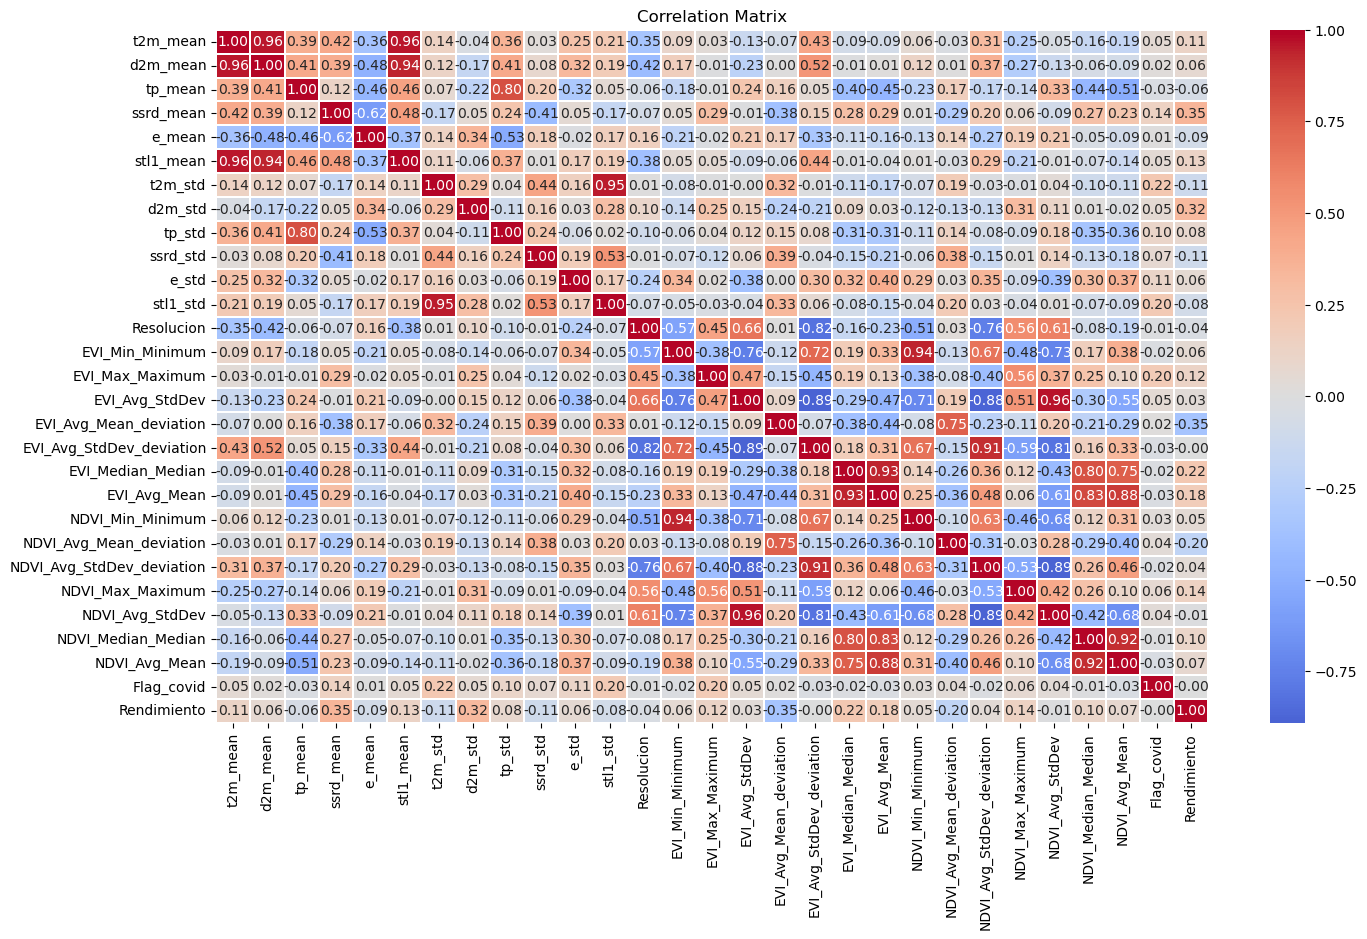

Rendimiento                  1.000000
ssrd_mean                    0.345375
d2m_std                      0.317942
EVI_Median_Median            0.222867
EVI_Avg_Mean                 0.181461
NDVI_Max_Maximum             0.137152
stl1_mean                    0.126328
EVI_Max_Maximum              0.120372
t2m_mean                     0.113964
NDVI_Median_Median           0.101897
tp_std                       0.077578
NDVI_Avg_Mean                0.074628
d2m_mean                     0.064966
EVI_Min_Minimum              0.057137
e_std                        0.056802
NDVI_Min_Minimum             0.053289
NDVI_Avg_StdDev_deviation    0.042170
EVI_Avg_StdDev               0.033591
EVI_Avg_StdDev_deviation    -0.001322
Flag_covid                  -0.003425
NDVI_Avg_StdDev             -0.007823
Resolucion                  -0.039692
tp_mean                     -0.062384
stl1_std                    -0.079675
e_mean                      -0.085023
ssrd_std                    -0.107822
t2m_std     

In [7]:
corr_matrix, corr_target_total = plot_corr_with_target(
    df_total_it,
    target='Rendimiento',
    drop_cols=['Mpio']
)

corr_target_total

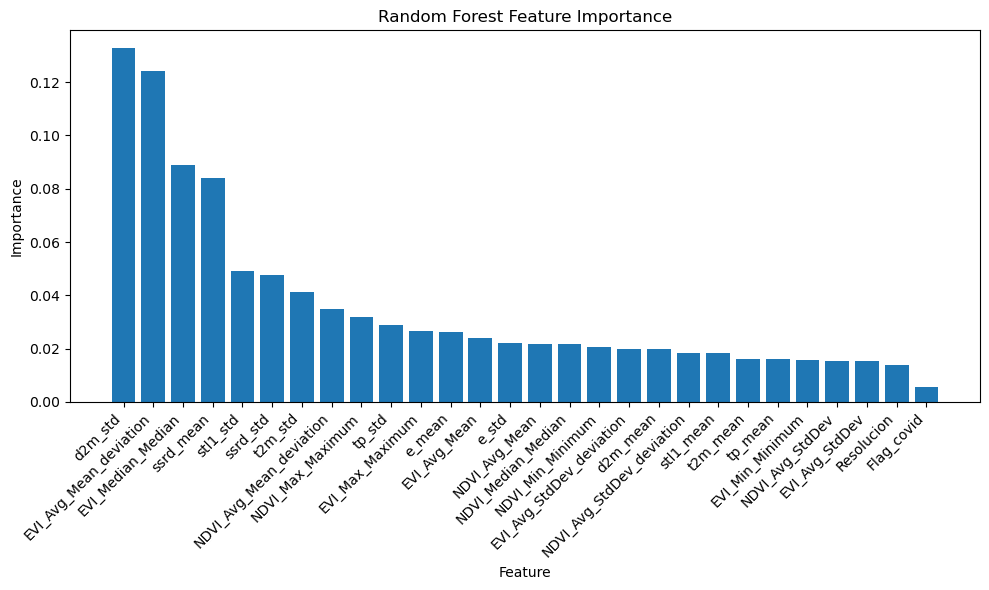

In [8]:
feat_imp_df_total, model = random_forest_feature_importance(
    df_total_it,
    target='Rendimiento',
    drop_cols=['Mpio']
)

# Vertical bar chart - Feature Importance
plt.figure(figsize=(10, 6))
plt.bar(feat_imp_df_total['feature'], feat_imp_df_total['importance'])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3.Revision agosto - noviembre

In [9]:
df_ago_nov_it = df_ago_nov[~df_ago_nov['Year'].isin([2024])]
df_ago_nov_it.drop(columns=['Year'], inplace=True)
df_ago_nov_it_dummies = pd.get_dummies(df_ago_nov_it, drop_first=True)

In [10]:
total_regressions_ago_nov = univariate_ols_analysis(df_ago_nov_it_dummies, target='Rendimiento')


Resultados para predictor: t2m_mean
                            OLS Regression Results                            
Dep. Variable:            Rendimiento   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.267
Date:                Mon, 27 Apr 2026   Prob (F-statistic):              0.261
Time:                        22:23:04   Log-Likelihood:                -53.698
No. Observations:                 321   AIC:                             111.4
Df Residuals:                     319   BIC:                             118.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          

In [11]:
total_regressions_ago_nov.drop(columns=['variable_model'], inplace=True)
total_regressions_ago_nov

,predictor,R2,F_stat,coef,p_value
0,ssrd_mean,0.078743,27.266037,1.094661e-07,3.204292e-07
1,EVI_Avg_Mean_deviation,0.066752,22.817006,-4.672227e+00,2.721376e-06
2,ssrd_std,0.049251,16.524986,-1.277621e-07,6.052755e-05
3,EVI_Median_Median,0.047441,15.887485,2.131411e+00,8.336812e-05
4,e_std,0.045206,15.103621,-6.186032e+02,1.237972e-04
5,EVI_Avg_Mean,0.031291,10.304234,1.771812e+00,1.462344e-03
6,NDVI_Max_Maximum,0.019151,6.228595,1.542794e+00,1.307509e-02
7,e_mean,0.016512,5.355806,-1.986784e+02,2.128829e-02
8,d2m_std,0.015205,4.925197,1.449407e-01,2.717091e-02
9,EVI_Max_Maximum,0.013017,4.207184,8.377369e-01,4.106955e-02


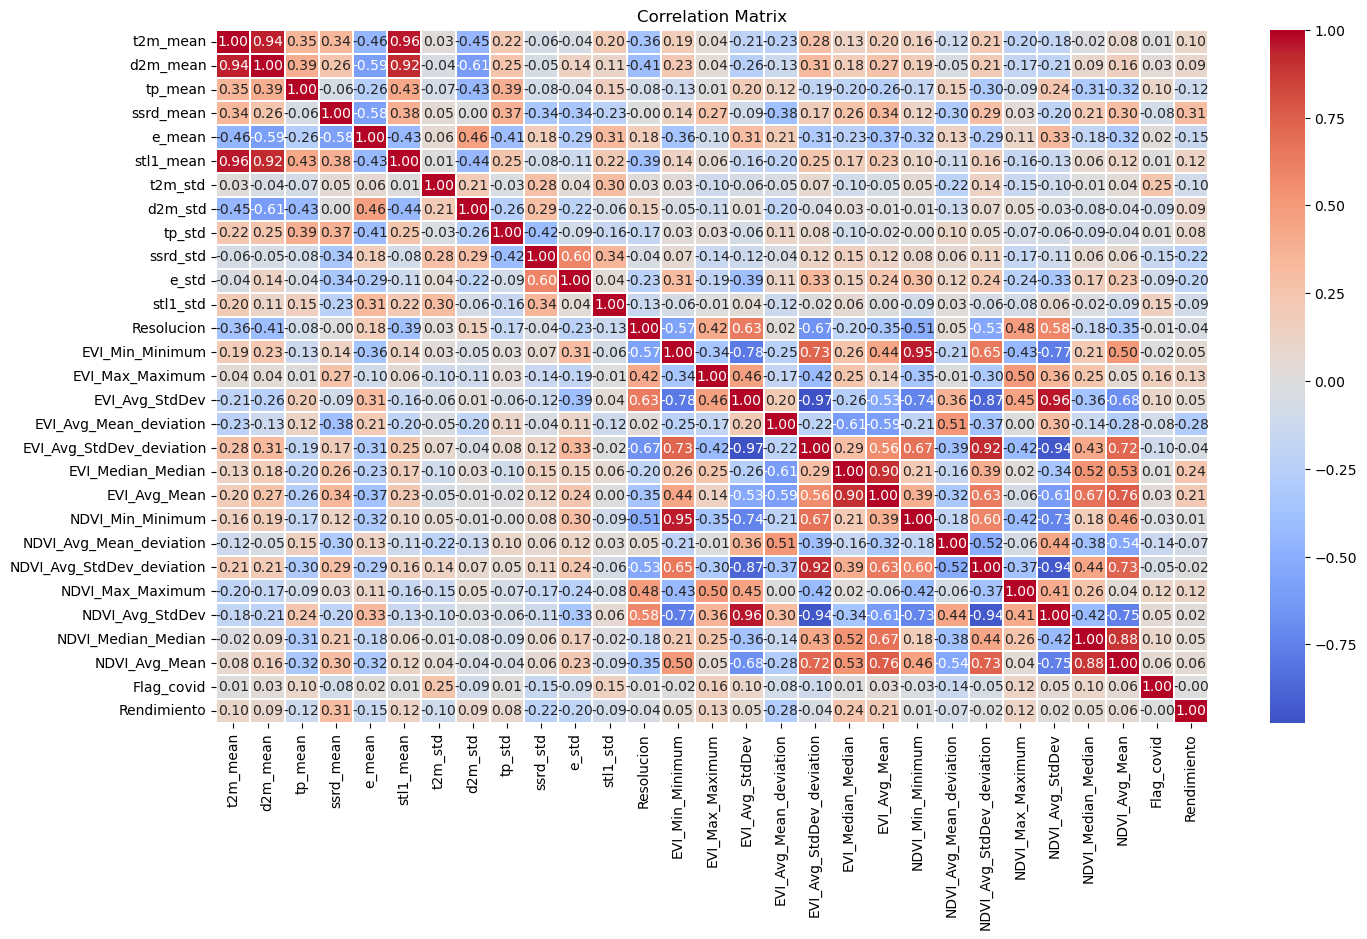

Rendimiento                  1.000000
ssrd_mean                    0.305417
EVI_Median_Median            0.240225
EVI_Avg_Mean                 0.214356
EVI_Max_Maximum              0.131397
stl1_mean                    0.124482
NDVI_Max_Maximum             0.118384
t2m_mean                     0.103988
d2m_std                      0.093220
d2m_mean                     0.090209
tp_std                       0.080051
NDVI_Avg_Mean                0.057740
NDVI_Median_Median           0.049383
EVI_Avg_StdDev               0.046912
EVI_Min_Minimum              0.045086
NDVI_Avg_StdDev              0.021494
NDVI_Min_Minimum             0.011222
Flag_covid                  -0.003425
NDVI_Avg_StdDev_deviation   -0.016118
Resolucion                  -0.039692
EVI_Avg_StdDev_deviation    -0.042830
NDVI_Avg_Mean_deviation     -0.065347
stl1_std                    -0.087448
t2m_std                     -0.101348
tp_mean                     -0.115313
e_mean                      -0.153583
e_std       

In [12]:
corr_matrix, corr_target_ago_nov = plot_corr_with_target(
    df_ago_nov_it,
    target='Rendimiento',
    drop_cols=['Mpio']
)

corr_target_ago_nov

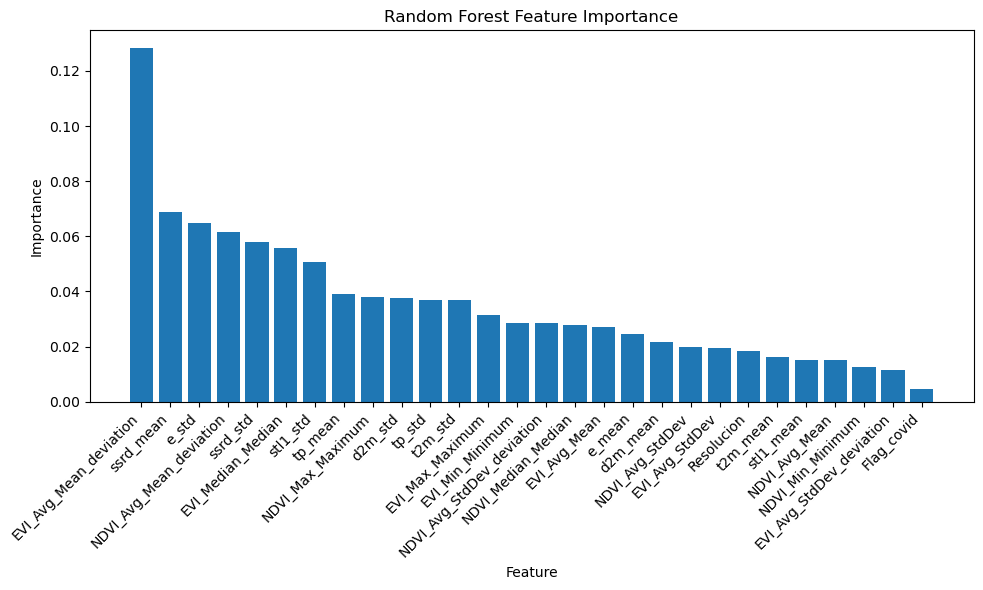

In [13]:
feat_imp_df_ago_nov, model = random_forest_feature_importance(
    df_ago_nov_it,
    target='Rendimiento',
    drop_cols=['Mpio']
)

# Vertical bar chart - Feature Importance
plt.figure(figsize=(10, 6))
plt.bar(feat_imp_df_ago_nov['feature'], feat_imp_df_ago_nov['importance'])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4.Revision septiembre - diciembre

In [14]:
df_sep_dec_it = df_sep_dec[~df_sep_dec['Year'].isin([2024])]
df_sep_dec_it.drop(columns=['Year'], inplace=True)
df_sep_dec_it_dummies = pd.get_dummies(df_sep_dec_it, drop_first=True)

In [15]:
total_regressions_sep_dec = univariate_ols_analysis(df_sep_dec_it_dummies, target='Rendimiento')


Resultados para predictor: t2m_mean
                            OLS Regression Results                            
Dep. Variable:            Rendimiento   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.670
Date:                Mon, 27 Apr 2026   Prob (F-statistic):              0.197
Time:                        22:23:08   Log-Likelihood:                -53.495
No. Observations:                 321   AIC:                             111.0
Df Residuals:                     319   BIC:                             118.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          

In [16]:
total_regressions_sep_dec.drop(columns=['variable_model'], inplace=True)
total_regressions_sep_dec

,predictor,R2,F_stat,coef,p_value
0,ssrd_std,0.094088,33.131212,-2.153619e-07,2.023046e-08
1,ssrd_mean,0.078518,27.181290,9.151252e-08,3.336325e-07
2,EVI_Avg_Mean_deviation,0.070415,24.163973,-5.349345e+00,1.417884e-06
3,e_std,0.052178,17.561079,-7.372383e+02,3.606317e-05
4,EVI_Median_Median,0.031582,10.403270,1.691355e+00,1.388322e-03
5,tp_std,0.031013,10.209916,4.535146e+01,1.536576e-03
6,d2m_std,0.026423,8.657742,2.240408e-01,3.495337e-03
7,EVI_Avg_Mean,0.026131,8.559356,1.594819e+00,3.684034e-03
8,EVI_Max_Maximum,0.017846,5.796385,9.936580e-01,1.662657e-02
9,NDVI_Max_Maximum,0.017413,5.653174,1.438234e+00,1.801281e-02


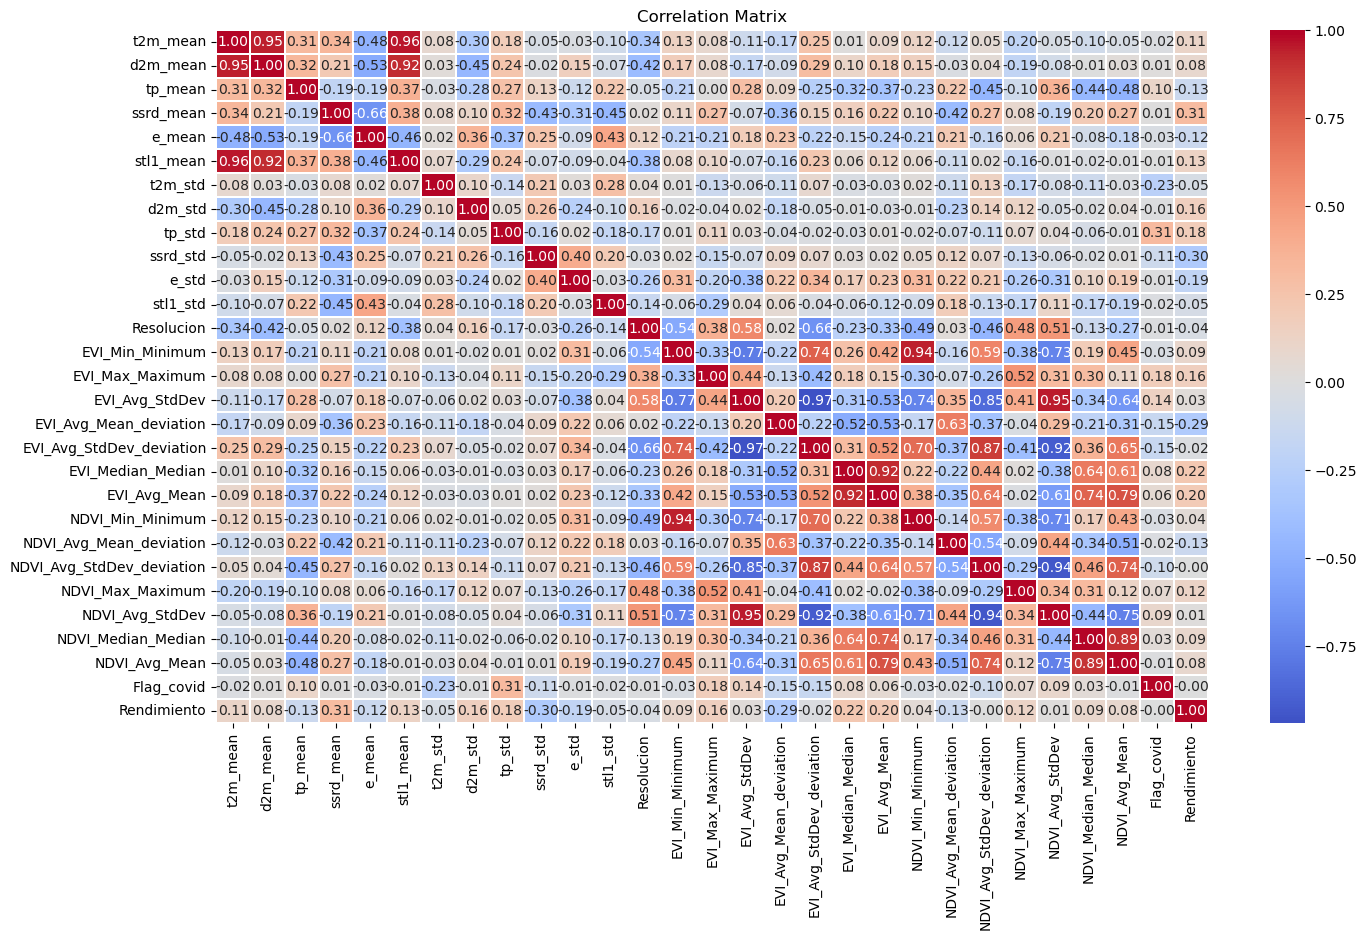

Rendimiento                  1.000000
ssrd_mean                    0.307337
EVI_Median_Median            0.218077
EVI_Avg_Mean                 0.197775
tp_std                       0.183798
EVI_Max_Maximum              0.156305
d2m_std                      0.155727
stl1_mean                    0.130521
NDVI_Max_Maximum             0.117966
t2m_mean                     0.113779
NDVI_Median_Median           0.090707
EVI_Min_Minimum              0.086460
NDVI_Avg_Mean                0.080892
d2m_mean                     0.079534
NDVI_Min_Minimum             0.043094
EVI_Avg_StdDev               0.026936
NDVI_Avg_StdDev              0.008931
Flag_covid                  -0.003425
NDVI_Avg_StdDev_deviation   -0.003505
EVI_Avg_StdDev_deviation    -0.020935
Resolucion                  -0.039692
t2m_std                     -0.051290
stl1_std                    -0.054450
e_mean                      -0.124698
tp_mean                     -0.127393
NDVI_Avg_Mean_deviation     -0.128225
e_std       

In [17]:
corr_matrix, corr_target_sep_dec = plot_corr_with_target(
    df_sep_dec_it,
    target='Rendimiento',
    drop_cols=['Mpio']
)

corr_target_sep_dec

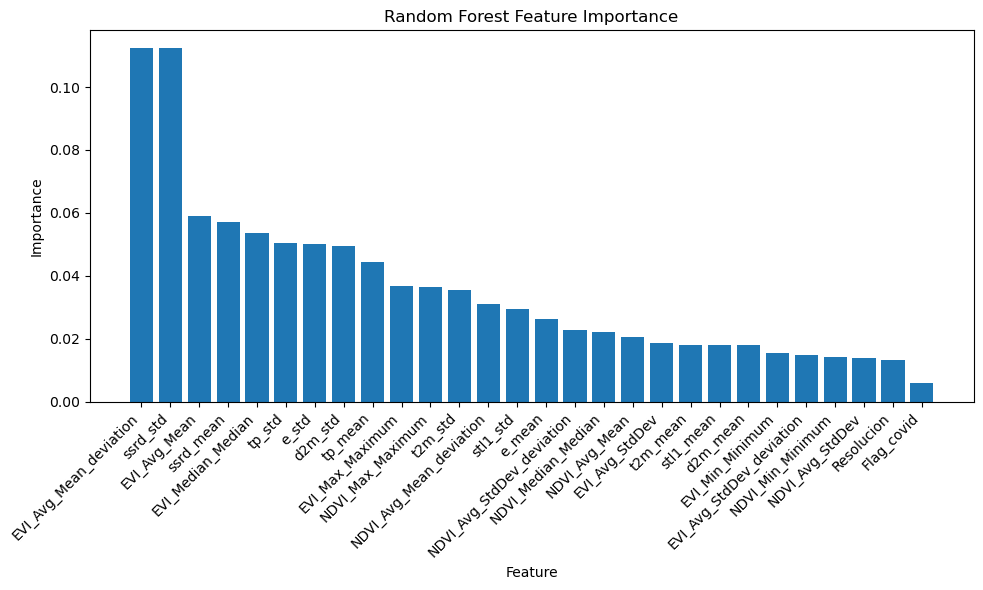

In [18]:
feat_imp_df_sep_dec, model = random_forest_feature_importance(
    df_sep_dec_it,
    target='Rendimiento',
    drop_cols=['Mpio']
)

# Vertical bar chart - Feature Importance
plt.figure(figsize=(10, 6))
plt.bar(feat_imp_df_sep_dec['feature'], feat_imp_df_sep_dec['importance'])
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Random Forest Feature Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5.Totales

In [19]:
# Información de regresiones univariadas
total_regressions_total = total_regressions.add_suffix('_total')
total_regressions_total.rename(columns={'predictor_total': 'predictor'}, inplace=True)
total_regressions_ago_nov = total_regressions_ago_nov.add_suffix('_ago_nov')
total_regressions_ago_nov.rename(columns={'predictor_ago_nov': 'predictor'}, inplace=True)
total_regressions_sep_dec = total_regressions_sep_dec.add_suffix('_sep_dec')
total_regressions_sep_dec.rename(columns={'predictor_sep_dec': 'predictor'}, inplace=True)

unified_regressions = total_regressions_total.merge(
    total_regressions_ago_nov, on=['predictor'], how='left').merge(
    total_regressions_sep_dec, on=['predictor'], how='left')

unified_regressions['rank_total'] = unified_regressions['R2_total'].rank(ascending=False, method='min').astype(int)
unified_regressions['rank_ago_nov'] = unified_regressions['R2_ago_nov'].rank(ascending=False, method='min').astype(int)
unified_regressions['rank_sep_dec'] = unified_regressions['R2_sep_dec'].rank(ascending=False, method='min').astype(int)
unified_regressions

,predictor,R2_total,F_stat_total,coef_total,p_value_total,R2_ago_nov,F_stat_ago_nov,coef_ago_nov,p_value_ago_nov,R2_sep_dec,F_stat_sep_dec,coef_sep_dec,p_value_sep_dec,rank_total,rank_ago_nov,rank_sep_dec
0,EVI_Avg_Mean_deviation,0.110143,39.484364,-8.566629e+00,1.083981e-09,0.066752,22.817006,-4.672227e+00,2.721376e-06,0.070415,24.163973,-5.349345e+00,1.417884e-06,1,2,3
1,d2m_std,0.104328,37.157085,5.910682e-01,3.143080e-09,0.015205,4.925197,1.449407e-01,2.717091e-02,0.026423,8.657742,2.240408e-01,3.495337e-03,2,9,7
2,ssrd_mean,0.103603,36.869262,1.458664e-07,3.587486e-09,0.078743,27.266037,1.094661e-07,3.204292e-07,0.078518,27.181290,9.151252e-08,3.336325e-07,3,1,2
3,EVI_Median_Median,0.036779,12.180327,1.952234e+00,5.509269e-04,0.047441,15.887485,2.131411e+00,8.336812e-05,0.031582,10.403270,1.691355e+00,1.388322e-03,4,4,5
4,NDVI_Avg_Mean_deviation,0.029399,9.662185,-4.178684e+00,2.050384e-03,0.002124,0.679093,-7.634319e-01,4.105149e-01,0.010157,3.273454,-1.748567e+00,7.135045e-02,5,23,12
5,NDVI_Max_Maximum,0.026370,8.639803,1.783621e+00,3.528990e-03,0.019151,6.228595,1.542794e+00,1.307509e-02,0.017413,5.653174,1.438234e+00,1.801281e-02,6,7,10
6,EVI_Avg_Mean,0.022767,7.432013,1.496042e+00,6.761433e-03,0.031291,10.304234,1.771812e+00,1.462344e-03,0.026131,8.559356,1.594819e+00,3.684034e-03,7,6,8
7,EVI_Max_Maximum,0.018026,5.855763,9.316490e-01,1.608470e-02,0.013017,4.207184,8.377369e-01,4.106955e-02,0.017846,5.796385,9.936580e-01,1.662657e-02,8,10,9
8,stl1_mean,0.008977,2.889580,1.932826e-02,9.012894e-02,0.008006,2.574398,1.871093e-02,1.095950e-01,0.008804,2.833304,1.944754e-02,9.330655e-02,9,13,15
9,t2m_std,0.008614,2.771586,-1.685362e-01,9.693286e-02,0.006573,2.110665,-2.698707e-01,1.472587e-01,0.004061,1.300677,-1.918712e-01,2.549452e-01,10,14,18


In [20]:
# Reorder columns to have feature first, then R2 columns, then rank columns
cols = ['predictor', 
        'R2_total', 'R2_ago_nov', 'R2_sep_dec',
        'rank_total', 'rank_ago_nov', 'rank_sep_dec']
unified_regressions_scale = unified_regressions[cols]

# Sort by rank_total
unified_regressions_scale = unified_regressions_scale.sort_values(by='rank_total').reset_index(drop=True)
unified_regressions_scale['Ranking_avg'] = (unified_regressions_scale['rank_total'] + unified_regressions_scale['rank_ago_nov'] + unified_regressions_scale['rank_sep_dec'])/3

unified_regressions_scale.sort_values(by='Ranking_avg', ascending= True, inplace=True)

unified_regressions_scale['top_total'] = np.where(unified_regressions_scale['rank_total'] <= 10, 1, 0)
unified_regressions_scale['top_ago_nov'] = np.where(unified_regressions_scale['rank_ago_nov'] <= 10, 1, 0)
unified_regressions_scale['top_sep_dec'] = np.where(unified_regressions_scale['rank_sep_dec'] <= 10, 1, 0)
unified_regressions_scale['top_count'] = unified_regressions_scale['top_total'] + unified_regressions_scale['top_ago_nov'] + unified_regressions_scale['top_sep_dec']

unified_regressions_scale

,predictor,R2_total,R2_ago_nov,R2_sep_dec,rank_total,rank_ago_nov,rank_sep_dec,Ranking_avg,top_total,top_ago_nov,top_sep_dec,top_count
0,EVI_Avg_Mean_deviation,0.110143,0.066752,0.070415,1,2,3,2.000000,1,1,1,3
2,ssrd_mean,0.103603,0.078743,0.078518,3,1,2,2.000000,1,1,1,3
3,EVI_Median_Median,0.036779,0.047441,0.031582,4,4,5,4.333333,1,1,1,3
11,ssrd_std,0.006758,0.049251,0.094088,12,3,1,5.333333,0,1,1,2
1,d2m_std,0.104328,0.015205,0.026423,2,9,7,6.000000,1,1,1,3
6,EVI_Avg_Mean,0.022767,0.031291,0.026131,7,6,8,7.000000,1,1,1,3
5,NDVI_Max_Maximum,0.026370,0.019151,0.017413,6,7,10,7.666667,1,1,1,3
7,EVI_Max_Maximum,0.018026,0.013017,0.017846,8,10,9,9.000000,1,1,1,3
23,e_std,0.000455,0.045206,0.052178,24,5,4,11.000000,0,1,1,2
14,e_mean,0.005614,0.016512,0.011632,15,8,11,11.333333,0,1,0,1


In [26]:
feats_select_regresion= list(unified_regressions_scale[unified_regressions_scale['top_count']>1]['predictor'])
feats_select_regresion

['EVI_Avg_Mean_deviation',
 'ssrd_mean',
 'EVI_Median_Median',
 'ssrd_std',
 'd2m_std',
 'EVI_Avg_Mean',
 'NDVI_Max_Maximum',
 'EVI_Max_Maximum',
 'e_std']

In [23]:
# Información de regresiones univariadas
feat_imp_df_total = feat_imp_df_total.add_suffix('_total')
feat_imp_df_total.rename(columns={'feature_total': 'feature'}, inplace=True)
feat_imp_df_ago_nov = feat_imp_df_ago_nov.add_suffix('_ago_nov')
feat_imp_df_ago_nov.rename(columns={'feature_ago_nov': 'feature'}, inplace=True)
feat_imp_df_sep_dec = feat_imp_df_sep_dec.add_suffix('_sep_dec')
feat_imp_df_sep_dec.rename(columns={'feature_sep_dec': 'feature'}, inplace=True)

unified_importances = feat_imp_df_total.merge(
    feat_imp_df_ago_nov, on=['feature'], how='left').merge(
    feat_imp_df_sep_dec, on=['feature'], how='left')

# Add ranking columns (1st to last) for each importance column
unified_importances['rank_total'] = unified_importances['importance_total'].rank(ascending=False, method='min').astype(int)
unified_importances['rank_ago_nov'] = unified_importances['importance_ago_nov'].rank(ascending=False, method='min').astype(int)
unified_importances['rank_sep_dec'] = unified_importances['importance_sep_dec'].rank(ascending=False, method='min').astype(int)

# Reorder columns to have feature first, then importance columns, then rank columns
cols = ['feature', 
        'importance_total', 'importance_ago_nov', 'importance_sep_dec',
        'rank_total', 'rank_ago_nov', 'rank_sep_dec']
unified_importances = unified_importances[cols]

# Sort by rank_total
unified_importances = unified_importances.sort_values(by='rank_total').reset_index(drop=True)
unified_importances['Ranking_avg'] = (unified_importances['rank_total'] + unified_importances['rank_ago_nov'] + unified_importances['rank_sep_dec'])/3

unified_importances.sort_values(by='Ranking_avg', ascending= True, inplace=True)

unified_importances['top_total'] = np.where(unified_importances['rank_total'] <= 10, 1, 0)
unified_importances['top_ago_nov'] = np.where(unified_importances['rank_ago_nov'] <= 10, 1, 0)
unified_importances['top_sep_dec'] = np.where(unified_importances['rank_sep_dec'] <= 10, 1, 0)
unified_importances['top_count'] = unified_importances['top_total'] + unified_importances['top_ago_nov'] + unified_importances['top_sep_dec']
unified_importances

,feature,importance_total,importance_ago_nov,importance_sep_dec,rank_total,rank_ago_nov,rank_sep_dec,Ranking_avg,top_total,top_ago_nov,top_sep_dec,top_count
1,EVI_Avg_Mean_deviation,0.124100,0.128286,0.112397,2,1,1,1.333333,1,1,1,3
3,ssrd_mean,0.084117,0.068832,0.057150,4,2,4,3.333333,1,1,1,3
5,ssrd_std,0.047705,0.058023,0.112370,6,5,2,4.333333,1,1,1,3
2,EVI_Median_Median,0.088741,0.055778,0.053523,3,6,5,4.666667,1,1,1,3
0,d2m_std,0.132847,0.037589,0.049475,1,10,8,6.333333,1,1,1,3
13,e_std,0.021896,0.064836,0.050180,14,3,7,8.000000,0,1,1,2
7,NDVI_Avg_Mean_deviation,0.034838,0.061653,0.031099,8,4,13,8.333333,1,1,0,2
4,stl1_std,0.049209,0.050825,0.029449,5,7,14,8.666667,1,1,0,2
9,tp_std,0.028964,0.037069,0.050542,10,11,6,9.000000,1,0,1,2
8,NDVI_Max_Maximum,0.031651,0.037944,0.036323,9,9,11,9.666667,1,1,0,2


In [32]:
unified_importances = feat_imp_df_total.merge(
    feat_imp_df_ago_nov, on=['feature'], how='left').merge(
    feat_imp_df_sep_dec, on=['feature'], how='left')

# Add ranking columns (1st to last) for each importance column
unified_importances['rank_total'] = unified_importances['importance_total'].rank(ascending=False, method='min').astype(int)
unified_importances['rank_ago_nov'] = unified_importances['importance_ago_nov'].rank(ascending=False, method='min').astype(int)
unified_importances['rank_sep_dec'] = unified_importances['importance_sep_dec'].rank(ascending=False, method='min').astype(int)

# Reorder columns to have feature first, then importance columns, then rank columns
cols = ['feature', 
        'importance_total', 'importance_ago_nov', 'importance_sep_dec',
        'rank_total', 'rank_ago_nov', 'rank_sep_dec']
unified_importances = unified_importances[cols]

# Sort by rank_total
unified_importances = unified_importances.sort_values(by='rank_total').reset_index(drop=True)
unified_importances['Ranking_avg'] = (unified_importances['rank_total'] + unified_importances['rank_ago_nov'] + unified_importances['rank_sep_dec'])/3

unified_importances.sort_values(by='Ranking_avg', ascending= True, inplace=True)

unified_importances['top_total'] = np.where(unified_importances['rank_total'] <= 10, 1, 0)
unified_importances['top_ago_nov'] = np.where(unified_importances['rank_ago_nov'] <= 10, 1, 0)
unified_importances['top_sep_dec'] = np.where(unified_importances['rank_sep_dec'] <= 10, 1, 0)
unified_importances['top_count'] = unified_importances['top_total'] + unified_importances['top_ago_nov'] + unified_importances['top_sep_dec']
unified_importances

,feature,importance_total,importance_ago_nov,importance_sep_dec,rank_total,rank_ago_nov,rank_sep_dec,Ranking_avg,top_total,top_ago_nov,top_sep_dec,top_count
1,EVI_Avg_Mean_deviation,0.124100,0.128286,0.112397,2,1,1,1.333333,1,1,1,3
3,ssrd_mean,0.084117,0.068832,0.057150,4,2,4,3.333333,1,1,1,3
5,ssrd_std,0.047705,0.058023,0.112370,6,5,2,4.333333,1,1,1,3
2,EVI_Median_Median,0.088741,0.055778,0.053523,3,6,5,4.666667,1,1,1,3
0,d2m_std,0.132847,0.037589,0.049475,1,10,8,6.333333,1,1,1,3
13,e_std,0.021896,0.064836,0.050180,14,3,7,8.000000,0,1,1,2
7,NDVI_Avg_Mean_deviation,0.034838,0.061653,0.031099,8,4,13,8.333333,1,1,0,2
4,stl1_std,0.049209,0.050825,0.029449,5,7,14,8.666667,1,1,0,2
9,tp_std,0.028964,0.037069,0.050542,10,11,6,9.000000,1,0,1,2
8,NDVI_Max_Maximum,0.031651,0.037944,0.036323,9,9,11,9.666667,1,1,0,2


In [34]:
feats_select_imp= list(unified_importances[unified_importances['top_count']>1]['feature'])
feats_select_imp

['EVI_Avg_Mean_deviation',
 'ssrd_mean',
 'ssrd_std',
 'EVI_Median_Median',
 'd2m_std',
 'e_std',
 'NDVI_Avg_Mean_deviation',
 'stl1_std',
 'tp_std',
 'NDVI_Max_Maximum',
 'tp_mean']